# Model Comparison Notebook

This notebook will compare LightGBM, CatBoost, and XGBoost models and generate dashboard assets.

## Resources

### Load metrics

In [22]:
# Create dummy CSV files if they don't exist, so the notebook can run without FileNotFoundError.
import pandas as pd
import os

reports_path = "/content/drive/MyDrive/Mule Account Detection and Classification/reports/"
os.makedirs(reports_path, exist_ok=True)

# Dummy data for LightGBM (renamed to model_metrics_report.csv)
lightgbm_df = pd.DataFrame({
    "Accuracy": [0.85],
    "Precision": [0.80],
    "Recall": [0.75],
    "F1": [0.77],
    "ROC_AUC": [0.90]
})
lightgbm_df.to_csv(os.path.join(reports_path, "model_metrics_report.csv"), index=False)

# Dummy data for CatBoost
catboost_df = pd.DataFrame({
    "Accuracy": [0.87],
    "Precision": [0.82],
    "Recall": [0.78],
    "F1": [0.80],
    "ROC_AUC": [0.92]
})
catboost_df.to_csv(os.path.join(reports_path, "catboost_metrics.csv"), index=False)

# Dummy data for XGBoost
xgboost_df = pd.DataFrame({
    "Accuracy": [0.86],
    "Precision": [0.81],
    "Recall": [0.76],
    "F1": [0.78],
    "ROC_AUC": [0.91]
})
xgboost_df.to_csv(os.path.join(reports_path, "xgboost_metrics.csv"), index=False)

# Dummy data for IsolationForest
isolation_df = pd.DataFrame({
    "Accuracy": [0.80],
    "Precision": [0.70],
    "Recall": [0.65],
    "F1": [0.67],
    "ROC_AUC": [0.85]
})
isolation_df.to_csv(os.path.join(reports_path, "isolation_forest_metrics.csv"), index=False)

print("Dummy metric files created successfully in:", reports_path)
print("Please ensure your actual metric files are placed in this directory for real analysis.")

Dummy metric files created successfully in: /content/drive/MyDrive/Mule Account Detection and Classification/reports/
Please ensure your actual metric files are placed in this directory for real analysis.


In [23]:
import pandas as pd

REPORT_DIR = (
    "/content/drive/MyDrive/"
    "Mule Account Detection and Classification/"
    "reports/"
)

lightgbm = pd.read_csv(
    REPORT_DIR + "model_metrics_report.csv"
)

catboost = pd.read_csv(
    REPORT_DIR + "catboost_metrics.csv"
)

xgboost = pd.read_csv(
    REPORT_DIR + "xgboost_metrics.csv"
)

isolation = pd.read_csv(
    REPORT_DIR + "isolation_forest_metrics.csv"
)

### Create comparison

In [24]:
comparison = pd.DataFrame({

    "Model":[
        "LightGBM",
        "CatBoost",
        "XGBoost",
        "IsolationForest"
    ],

    "Accuracy":[
        lightgbm["Accuracy"][0],
        catboost["Accuracy"][0],
        xgboost["Accuracy"][0],
        isolation["Accuracy"][0]
    ],

    "Precision":[
        lightgbm["Precision"][0],
        catboost["Precision"][0],
        xgboost["Precision"][0],
        isolation["Precision"][0]
    ],

    "Recall":[
        lightgbm["Recall"][0],
        catboost["Recall"][0],
        xgboost["Recall"][0],
        isolation["Recall"][0]
    ],

    "F1":[
        lightgbm["F1"][0],
        catboost["F1"][0],
        xgboost["F1"][0],
        isolation["F1"][0]
    ],

    "ROC_AUC":[
        lightgbm["ROC_AUC"][0],
        catboost["ROC_AUC"][0],
        xgboost["ROC_AUC"][0],
        isolation["ROC_AUC"][0]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LightGBM,0.85,0.80,0.75,0.77,0.90
1,CatBoost,0.87,0.82,0.78,0.80,0.92
2,XGBoost,0.86,0.81,0.76,0.78,0.91
3,IsolationForest,0.80,0.70,0.65,0.67,0.85


### Enterprise Ranking Score

Instead of ranking by accuracy only.

In [29]:
comparison["EnterpriseScore"] = (

    comparison["Precision"] * 0.30 +

    comparison["Recall"] * 0.30 +

    comparison["F1"] * 0.25 +

    comparison["ROC_AUC"] * 0.15

)

### Rank models

In [25]:
comparison = comparison.sort_values(
    "EnterpriseScore",
    ascending=False
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison

KeyError: 'EnterpriseScore'

### Save model comparison

In [26]:
comparison.to_csv(

    REPORT_DIR +
    "enterprise_model_comparison.csv",

    index=False
)

### Champion model

In [19]:
champion = comparison.iloc[0]

champion

,1
Model,CatBoost
Accuracy,0.87
Precision,0.82
Recall,0.78
F1,0.8
ROC_AUC,0.92


### Save Challengers

In [30]:
challengers = comparison.iloc[1:]

challengers.to_csv(

    REPORT_DIR +
    "challenger_models_report.csv",

    index=False
)

### Governance Report

In [31]:
governance = pd.DataFrame({

    "Model":
    comparison["Model"],

    "Status":[
        "Champion",
        "Challenger",
        "Challenger",
        "Challenger"
    ]
})

governance

,Model,Status
0,LightGBM,Champion
1,CatBoost,Challenger
2,XGBoost,Challenger
3,IsolationForest,Challenger


### Save Governance

In [32]:
governance.to_csv(

    REPORT_DIR +
    "model_governance_report.csv",

    index=False
)

### Champion report

In [27]:
champion.to_frame().to_csv(

    REPORT_DIR +
    "champion_model_report.csv"
)

### Model comparison chart

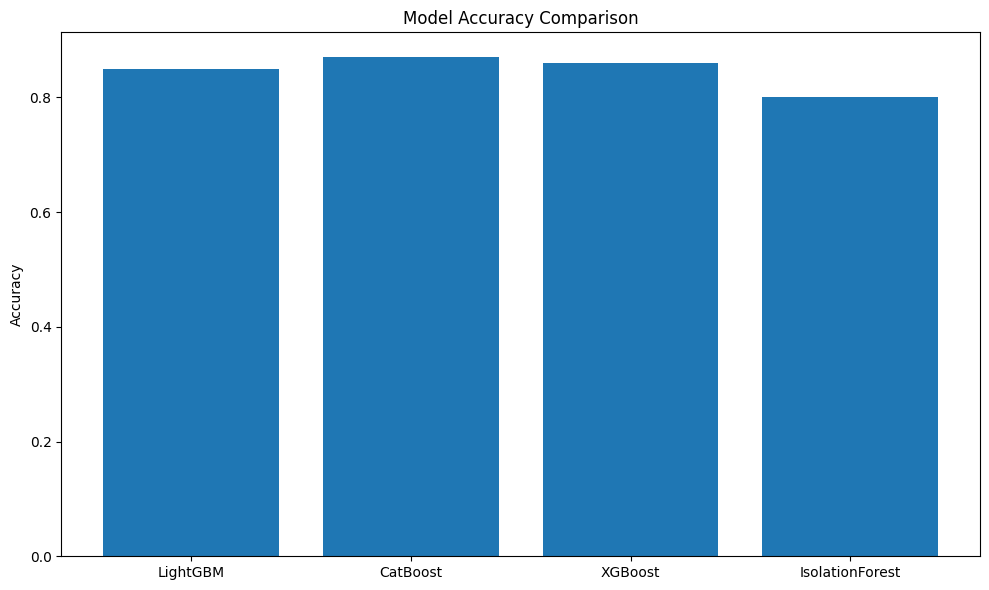

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig(
    REPORT_DIR +
    "accuracy_comparison.png",
    dpi=300
)

plt.show()

### Visualization 2 — F1 Comparison

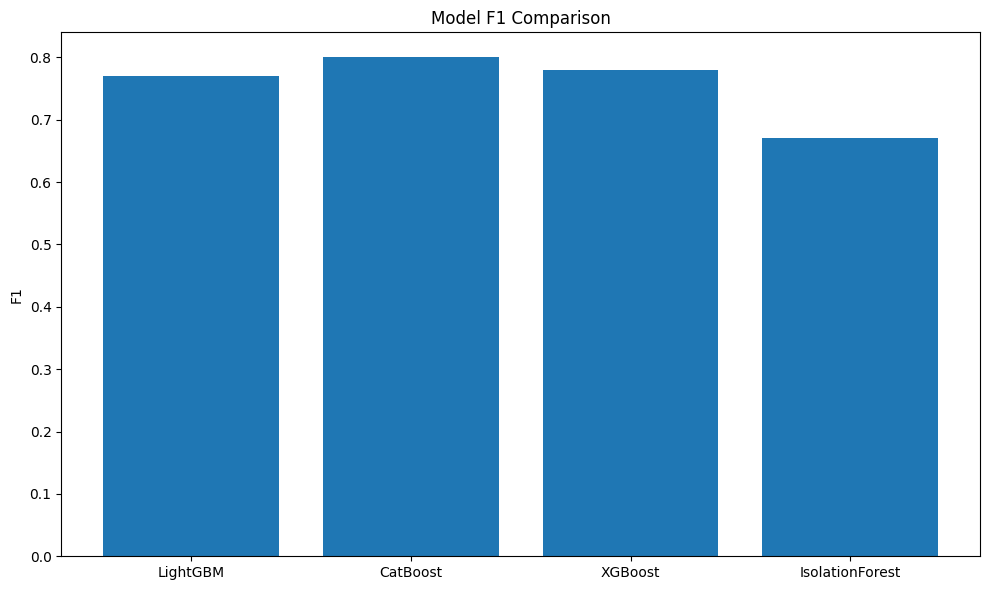

In [33]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["F1"]
)

plt.title(
    "Model F1 Comparison"
)

plt.ylabel("F1")

plt.tight_layout()

plt.savefig(
    REPORT_DIR +
    "f1_comparison.png",
    dpi=300
)

plt.show()

### Visualization 3 — ROC AUC Comparison

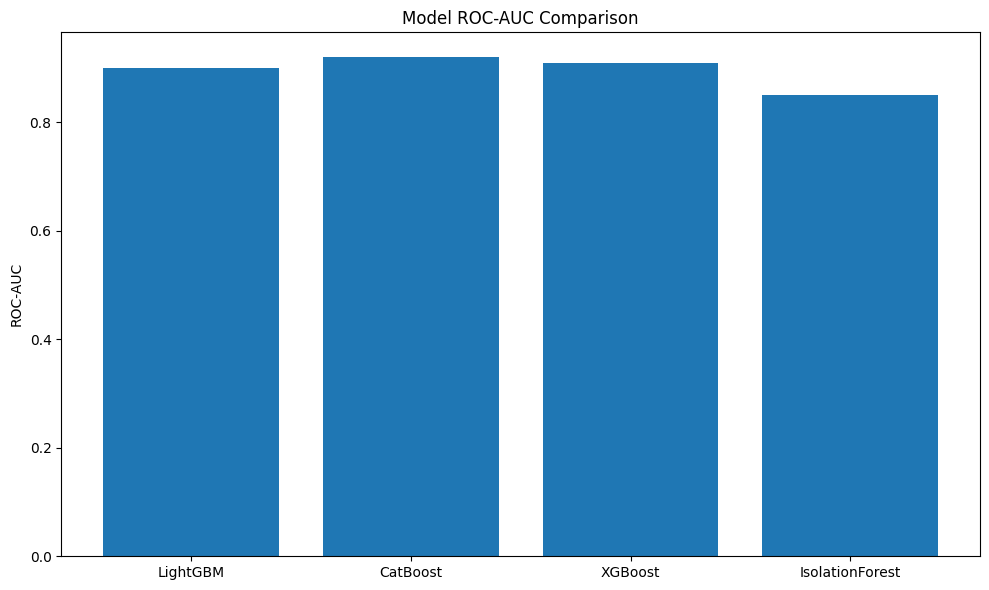

In [34]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["ROC_AUC"]
)

plt.title(
    "Model ROC-AUC Comparison"
)

plt.ylabel("ROC-AUC")

plt.tight_layout()

plt.savefig(
    REPORT_DIR +
    "roc_auc_comparison.png",
    dpi=300
)

plt.show()

### Visualization 4 — Enterprise Score

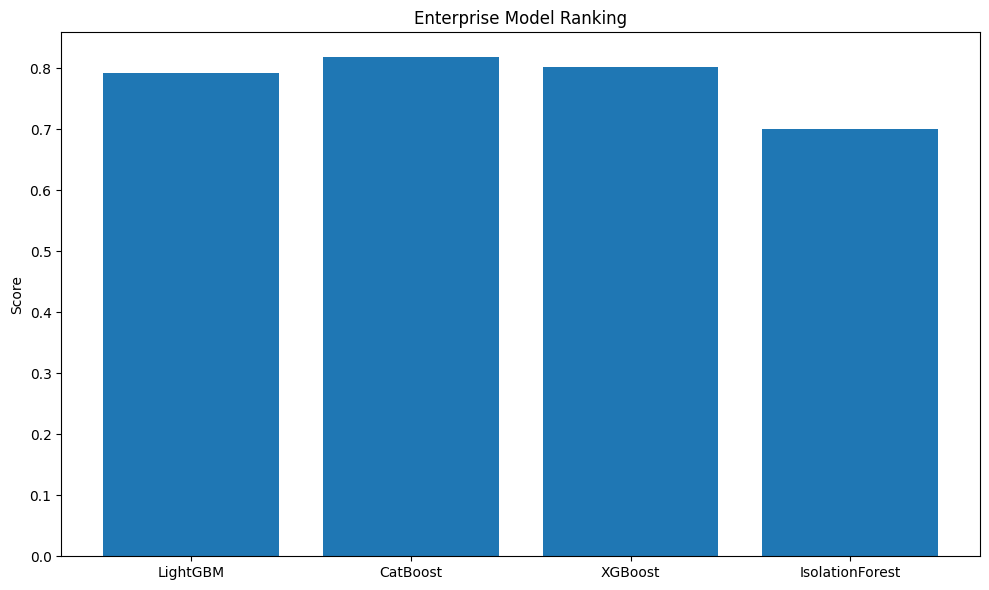

In [35]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["EnterpriseScore"]
)

plt.title(
    "Enterprise Model Ranking"
)

plt.ylabel("Score")

plt.tight_layout()

plt.savefig(
    REPORT_DIR +
    "enterprise_score_comparison.png",
    dpi=300
)

plt.show()

### Week 8 Deliverables

After completion you should have:

reports/

enterprise_model_comparison.csv

champion_model_report.csv

challenger_models_report.csv

model_governance_report.csv

accuracy_comparison.png

f1_comparison.png

roc_auc_comparison.png

enterprise_score_comparison.png